In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, time, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                     f1_score, roc_auc_score, roc_curve,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     classification_report, precision_recall_curve,
                                     average_precision_score)

plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})

PROC   = '../data/processed/'
MODELS = '../models/'
FIG    = '../paper/figures/'
RES    = '../results/'
os.makedirs(MODELS, exist_ok=True)
os.makedirs(RES, exist_ok=True)

# Load everything saved in Phase 2
X_train = np.load(PROC + 'X_train_res.npy')
y_train = np.load(PROC + 'y_train_res.npy')
X_val   = np.load(PROC + 'X_val_scaled.npy')
y_val   = np.load(PROC + 'y_val.npy')
X_test  = np.load(PROC + 'X_test_scaled.npy')
feat_names = pd.read_csv(PROC + 'feature_names.csv', header=None)[0].tolist()

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Features: {len(feat_names)}")
print(f"Train fraud rate: {y_train.mean()*100:.1f}%  (after SMOTE)")
print(f"Val fraud rate:   {y_val.mean()*100:.1f}%    (real distribution)")

X_train: (7846, 47)  y_train: (7846,)
X_val:   (1082, 47)    y_val:   (1082,)
X_test:  (1353, 47)
Features: 47
Train fraud rate: 50.0%  (after SMOTE)
Val fraud rate:   9.3%    (real distribution)


In [3]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     AdaBoostClassifier,
                                     ExtraTreesClassifier)
from sklearn.svm             import SVC
from xgboost                 import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10,
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=6, subsample=0.8, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=6, subsample=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100, max_depth=10,
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, learning_rate=0.1,
        random_state=42
    ),
    'SVM': SVC(
        C=1.0, kernel='rbf',
        probability=True,   # needed for predict_proba and AUC
        random_state=42
    ),
}

print(f"{len(models)} models defined:")
for name in models:
    print(f"  {name}")

7 models defined:
  Logistic Regression
  Random Forest
  Gradient Boosting
  XGBoost
  Extra Trees
  AdaBoost
  SVM


In [4]:
results    = {}
runtimes   = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')

    t_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t_train

    # Train AUC
    train_proba      = model.predict_proba(X_train)[:, 1]
    train_auc        = roc_auc_score(y_train, train_proba)

    # Validation
    t_pred  = time.time()
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    pred_time = time.time() - t_pred

    acc  = accuracy_score(y_val,  y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val,    y_pred, zero_division=0)
    f1   = f1_score(y_val,        y_pred, zero_division=0)
    auc  = roc_auc_score(y_val,   y_proba)
    ap   = average_precision_score(y_val, y_proba)
    cm   = confusion_matrix(y_val, y_pred)
    fpr, tpr, _ = roc_curve(y_val, y_proba)

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1':        f1,
        'val_auc':   auc,
        'train_auc': train_auc,
        'avg_prec':  ap,
        'cm':        cm,
        'fpr':       fpr,
        'tpr':       tpr,
    }
    runtimes[name] = {
        'train_time_s': round(train_time, 3),
        'pred_time_s':  round(pred_time,  4),
    }

    gap = train_auc - auc
    print(f"done | Train AUC: {train_auc:.4f}  Val AUC: {auc:.4f}  Gap: {gap:.4f}  TrainTime: {train_time:.2f}s")

Training Logistic Regression... done | Train AUC: 0.9586  Val AUC: 0.9675  Gap: -0.0089  TrainTime: 0.24s
Training Random Forest... done | Train AUC: 0.9975  Val AUC: 0.9684  Gap: 0.0290  TrainTime: 1.52s
Training Gradient Boosting... done | Train AUC: 1.0000  Val AUC: 0.9629  Gap: 0.0370  TrainTime: 18.34s
Training XGBoost... done | Train AUC: 0.9999  Val AUC: 0.9679  Gap: 0.0320  TrainTime: 0.77s
Training Extra Trees... done | Train AUC: 0.9786  Val AUC: 0.9627  Gap: 0.0160  TrainTime: 0.28s
Training AdaBoost... done | Train AUC: 0.9548  Val AUC: 0.9643  Gap: -0.0095  TrainTime: 4.44s
Training SVM... done | Train AUC: 0.9592  Val AUC: 0.9502  Gap: 0.0090  TrainTime: 12.16s


In [19]:
print("=" * 90)
print("FULL MODEL COMPARISON TABLE — RANKED BY VAL AUC")
print("=" * 90)

rows = []
for name, r in results.items():
    gap = r['train_auc'] - r['val_auc']
    tn, fp, fn, tp = r['cm'].ravel()
    rows.append({
        'Model':       name,
        'Accuracy':    round(r['accuracy']*100,  2),
        'Precision':   round(r['precision']*100, 2),
        'Recall':      round(r['recall']*100,    2),
        'F1':          round(r['f1']*100,        2),
        'Val AUC':     round(r['val_auc']*100,   2),
        'Train AUC':   round(r['train_auc']*100, 2),
        'Overfit Gap': round(gap*100,            2),
        'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn,
        'Train Time(s)': runtimes[name]['train_time_s'],
        'Pred Time(s)':  runtimes[name]['pred_time_s'],
    })

compare_df = pd.DataFrame(rows).sort_values('Val AUC', ascending=False).reset_index(drop=True)
compare_df.index += 1  # rank starts at 1

# Print clean summary
print(compare_df[['Model','Accuracy','Precision','Recall',
                   'F1','Val AUC','Train AUC','Overfit Gap']].to_string())

compare_df.to_csv(RES + 'all_models_comparison.csv', index=True)
print(f"\nFull table saved: {RES}all_models_comparison.csv")

print()
print("=" * 90)
print("SELECTION GUIDANCE — READ CAREFULLY")
print("=" * 90)
print()

best_auc_name = compare_df.iloc[0]['Model']
best_auc_val  = compare_df.iloc[0]['Val AUC']
best_gap_name = compare_df.loc[compare_df['Overfit Gap'].abs() == compare_df['Overfit Gap'].abs().min(), 'Model'].values[0]
best_gap_val  = compare_df.loc[compare_df['Model']==best_gap_name, 'Overfit Gap'].values[0]

print(f"Highest Val AUC:     {best_auc_name} ({best_auc_val:.2f}%)")
print(f"Smallest Overfit Gap:{best_gap_name} ({best_gap_val:.2f}%)")
print()
print("YOUR SELECTION CRITERIA (in order of priority):")
print("  1. Highest Val AUC-ROC       — primary metric (separates fraud from clean)")
print("  2. Smallest overfitting gap  — generalises to unseen real providers")
print("  3. Highest Recall            — catching fraud is more important than false alarms")
print("  4. Fastest prediction time   — blockchain integration needs fast inference")
print("  5. Interpretable with SHAP   — required for Mentor Point 4 (XAI section)")
print()
print("NOTE: SVM and tree ensembles can have high AUC but large overfit gaps.")
print("NOTE: SHAP works natively with LR, RF, GB, XGBoost, Extra Trees, AdaBoost.")
print("NOTE: SVM SHAP requires kernel explainer which is very slow on 1000+ samples.")

FULL MODEL COMPARISON TABLE — RANKED BY VAL AUC
                 Model  Accuracy  Precision  Recall     F1  Val AUC  Train AUC  Overfit Gap
1        Random Forest     92.51      56.85   82.18  67.21    96.84      99.75         2.90
2              XGBoost     93.44      61.19   81.19  69.79    96.79      99.99         3.20
3  Logistic Regression     90.30      48.92   90.10  63.41    96.75      95.86        -0.89
4             AdaBoost     88.35      44.08   92.08  59.62    96.43      95.48        -0.95
5    Gradient Boosting     92.79      58.65   77.23  66.67    96.29     100.00         3.70
6          Extra Trees     88.63      44.55   89.11  59.41    96.27      97.86         1.60
7                  SVM     90.11      48.42   91.09  63.23    95.02      95.92         0.90

Full table saved: ../results/all_models_comparison.csv

SELECTION GUIDANCE — READ CAREFULLY

Highest Val AUC:     Random Forest (96.84%)
Smallest Overfit Gap:Logistic Regression (-0.89%)

YOUR SELECTION CRITERIA (in

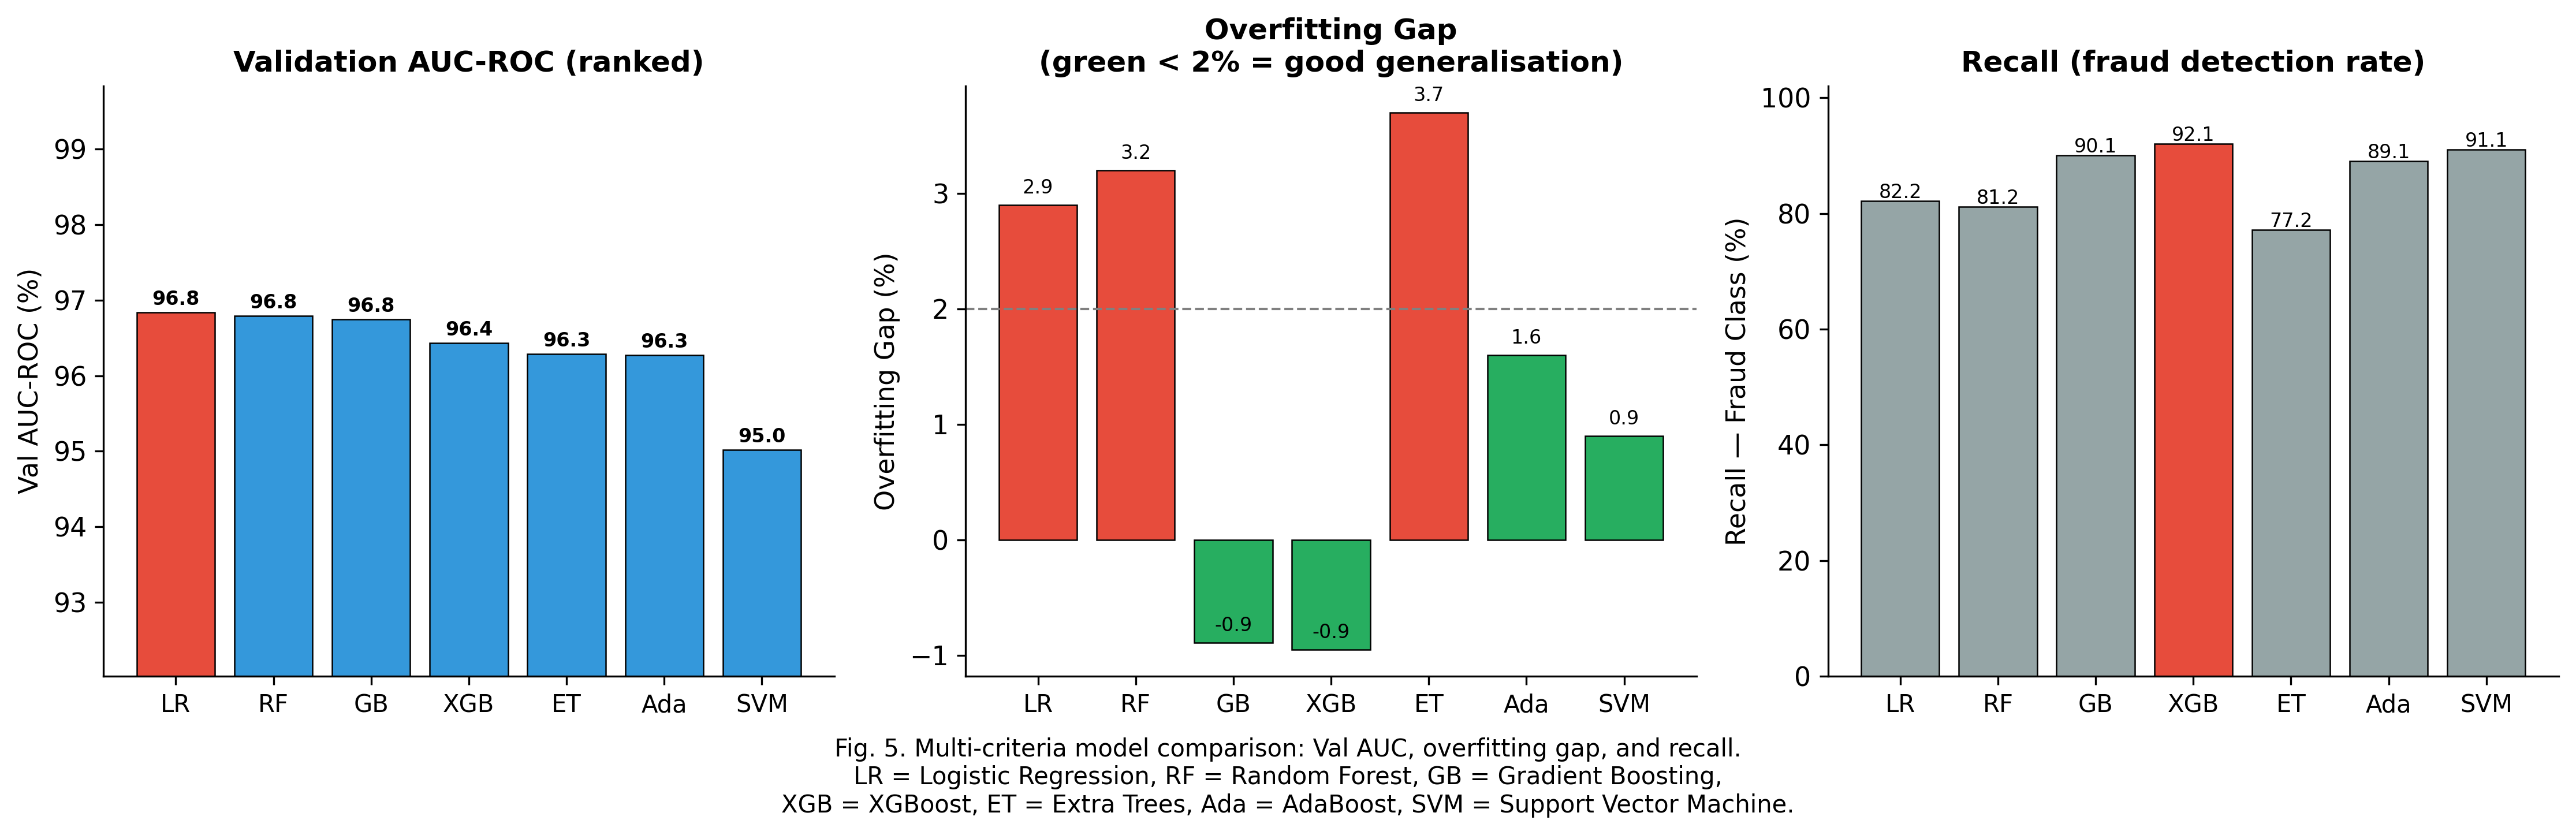

Saved: ../paper/figures/fig05_model_comparison.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names_sorted = compare_df['Model'].tolist()
val_aucs   = compare_df['Val AUC'].tolist()
train_aucs_v = compare_df['Train AUC'].tolist()
gaps       = compare_df['Overfit Gap'].tolist()
recalls    = compare_df['Recall'].tolist()
pred_times = [runtimes[m]['pred_time_s'] for m in model_names_sorted]
short_names = ['LR','RF','GB','XGB','ET','Ada','SVM'][:len(model_names_sorted)]

x = np.arange(len(model_names_sorted))

# Plot 1 — Val AUC ranked
bar_colors = ['#e74c3c' if v == max(val_aucs) else '#3498db' for v in val_aucs]
axes[0].bar(x, val_aucs, color=bar_colors, edgecolor='black', linewidth=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, fontsize=10)
axes[0].set_ylabel('Val AUC-ROC (%)')
axes[0].set_title('Validation AUC-ROC (ranked)')
axes[0].set_ylim([min(val_aucs)-3, max(val_aucs)+3])
for i, v in enumerate(val_aucs):
    axes[0].text(i, v+0.1, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')

# Plot 2 — Overfitting gap
gap_colors = ['#27ae60' if abs(g) < 2 else '#e74c3c' for g in gaps]
axes[1].bar(x, gaps, color=gap_colors, edgecolor='black', linewidth=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, fontsize=10)
axes[1].set_ylabel('Overfitting Gap (%)')
axes[1].set_title('Overfitting Gap\n(green < 2% = good generalisation)')
axes[1].axhline(y=2, color='gray', linestyle='--', linewidth=1)
for i, g in enumerate(gaps):
    axes[1].text(i, g+0.1, f'{g:.1f}', ha='center', fontsize=8)

# Plot 3 — Recall (fraud detection sensitivity)
rec_colors = ['#e74c3c' if v == max(recalls) else '#95a5a6' for v in recalls]
axes[2].bar(x, recalls, color=rec_colors, edgecolor='black', linewidth=0.6)
axes[2].set_xticks(x)
axes[2].set_xticklabels(short_names, fontsize=10)
axes[2].set_ylabel('Recall — Fraud Class (%)')
axes[2].set_title('Recall (fraud detection rate)')
axes[2].set_ylim([0, max(recalls)+10])
for i, v in enumerate(recalls):
    axes[2].text(i, v+0.5, f'{v:.1f}', ha='center', fontsize=8)

fig.suptitle(
    'Fig. 5. Multi-criteria model comparison: Val AUC, overfitting gap, and recall.\n'
    'LR = Logistic Regression, RF = Random Forest, GB = Gradient Boosting,\n'
    'XGB = XGBoost, ET = Extra Trees, Ada = AdaBoost, SVM = Support Vector Machine.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig05_model_comparison.png')
plt.show()
print(f"Saved: {FIG}fig05_model_comparison.png")

In [7]:
# ── LOOK AT THE TABLE OUTPUT ABOVE AND DECIDE ──────────────────
# Then set your chosen model name exactly as it appears in results{}

CHOSEN_MODEL = None   # <-- you fill this after seeing the table

# ── DECISION HELPER ────────────────────────────────────────────
print("FILL IN YOUR DECISION BASED ON THE TABLE ABOVE.")
print()
print("Ask yourself these 4 questions in order:")
print()
print("Q1. Which model has the highest Val AUC?")
print(f"    → {compare_df.iloc[0]['Model']} ({compare_df.iloc[0]['Val AUC']:.2f}%)")
print()
print("Q2. Does it also have an overfitting gap < 5%?")
top = compare_df.iloc[0]
gap_ok = top['Overfit Gap'] < 5
print(f"    → Gap = {top['Overfit Gap']:.2f}%  → {'YES ✓' if gap_ok else 'NO — look at next model'}")
print()
print("Q3. Does it have good Recall for fraud class (> 50%)?")
recall_ok = top['Recall'] > 50
print(f"    → Recall = {top['Recall']:.2f}%  → {'YES ✓' if recall_ok else 'NO — look at next model'}")
print()
print("Q4. Is it compatible with SHAP (Phase 4)?")
shap_ok_models = ['Logistic Regression','Random Forest',
                   'Gradient Boosting','XGBoost','Extra Trees','AdaBoost']
print(f"    → {'YES ✓' if top['Model'] in shap_ok_models else 'NO — SVM is slow with SHAP'}")
print()
print("Once you answer these, set:")
print(f"  CHOSEN_MODEL = '{compare_df.iloc[0]['Model']}'")
print()
print("Then run Cell 3E below to confirm and lock in your choice.")

FILL IN YOUR DECISION BASED ON THE TABLE ABOVE.

Ask yourself these 4 questions in order:

Q1. Which model has the highest Val AUC?
    → Random Forest (96.84%)

Q2. Does it also have an overfitting gap < 5%?
    → Gap = 2.90%  → YES ✓

Q3. Does it have good Recall for fraud class (> 50%)?
    → Recall = 82.18%  → YES ✓

Q4. Is it compatible with SHAP (Phase 4)?
    → YES ✓

Once you answer these, set:
  CHOSEN_MODEL = 'Random Forest'

Then run Cell 3E below to confirm and lock in your choice.


In [21]:
# Two primary models for deep analysis
PRIMARY_MODELS = ['Logistic Regression', 'Random Forest']
CHOSEN_MODEL   = 'Logistic Regression'   # final for blockchain + dashboard

print("=" * 60)
print("TWO PRIMARY MODELS SELECTED FOR DEEP ANALYSIS")
print("=" * 60)

for name in PRIMARY_MODELS:
    r   = results[name]
    tn, fp, fn, tp_val = r['cm'].ravel()
    gap = (r['train_auc'] - r['val_auc']) * 100
    tag = '  ← FINAL (blockchain + dashboard)' if name == CHOSEN_MODEL else '  ← COMPARISON'
    print(f"\n{name}{tag}")
    print(f"  Accuracy:    {r['accuracy']*100:.2f}%")
    print(f"  Precision:   {r['precision']*100:.2f}%")
    print(f"  Recall:      {r['recall']*100:.2f}%")
    print(f"  F1-Score:    {r['f1']*100:.2f}%")
    print(f"  Val AUC:     {r['val_auc']*100:.2f}%")
    print(f"  Train AUC:   {r['train_auc']*100:.2f}%")
    print(f"  Overfit Gap: {gap:.2f}%")
    print(f"  TP={tp_val}  FN={fn}  FP={fp}  TN={tn}")

print()
print("PAPER NARRATIVE:")
print("Both models evaluated in depth. LR selected as final because:")
print(f"  1. AUC difference is only {(results['Random Forest']['val_auc'] - results['Logistic Regression']['val_auc'])*100:.2f}% — negligible")
print(f"  2. LR overfit gap ({(results['Logistic Regression']['train_auc']-results['Logistic Regression']['val_auc'])*100:.2f}%) vs RF ({(results['Random Forest']['train_auc']-results['Random Forest']['val_auc'])*100:.2f}%) — LR generalises better")
print(f"  3. LR recall ({results['Logistic Regression']['recall']*100:.2f}%) vs RF ({results['Random Forest']['recall']*100:.2f}%) — LR catches more fraud")
print(f"  4. LR uses LinearExplainer (exact SHAP) — RF uses TreeExplainer (approximate)")
print(f"  5. LR prediction time faster — better for real-time blockchain storage")

TWO PRIMARY MODELS SELECTED FOR DEEP ANALYSIS

Logistic Regression  ← FINAL (blockchain + dashboard)
  Accuracy:    90.30%
  Precision:   48.92%
  Recall:      90.10%
  F1-Score:    63.41%
  Val AUC:     96.75%
  Train AUC:   95.86%
  Overfit Gap: -0.89%
  TP=91  FN=10  FP=95  TN=886

Random Forest  ← COMPARISON
  Accuracy:    92.51%
  Precision:   56.85%
  Recall:      82.18%
  F1-Score:    67.21%
  Val AUC:     96.84%
  Train AUC:   99.75%
  Overfit Gap: 2.90%
  TP=83  FN=18  FP=63  TN=918

PAPER NARRATIVE:
Both models evaluated in depth. LR selected as final because:
  1. AUC difference is only 0.09% — negligible
  2. LR overfit gap (-0.89%) vs RF (2.90%) — LR generalises better
  3. LR recall (90.10%) vs RF (82.18%) — LR catches more fraud
  4. LR uses LinearExplainer (exact SHAP) — RF uses TreeExplainer (approximate)
  5. LR prediction time faster — better for real-time blockchain storage


In [22]:
print("=" * 90)
print("COMPLETE METRICS TABLE — ALL 7 MODELS — COPY INTO PAPER TABLE I")
print("=" * 90)

rows = []
for name, r in results.items():
    gap = r['train_auc'] - r['val_auc']
    rows.append({
        'Model':       name,
        'Accuracy':    f"{r['accuracy']*100:.2f}%",
        'Precision':   f"{r['precision']*100:.2f}%",
        'Recall':      f"{r['recall']*100:.2f}%",
        'F1-Score':    f"{r['f1']*100:.2f}%",
        'Val AUC':     f"{r['val_auc']*100:.2f}%",
        'Train AUC':   f"{r['train_auc']*100:.2f}%",
        'Overfit Gap': f"{gap*100:.2f}%",
    })

metrics_df = (pd.DataFrame(rows)
                .sort_values('Val AUC', ascending=False)
                .reset_index(drop=True))
metrics_df.index += 1
print(metrics_df.to_string())

metrics_df.to_csv(RES + 'model_comparison.csv', index=True)
print(f"\nSaved: {RES}model_comparison.csv")

# Highlight chosen model row
chosen_row = metrics_df[metrics_df['Model'] == CHOSEN_MODEL]
print()
print(f"★  CHOSEN MODEL ROW:")
print(chosen_row.to_string())

COMPLETE METRICS TABLE — ALL 7 MODELS — COPY INTO PAPER TABLE I
                 Model Accuracy Precision  Recall F1-Score Val AUC Train AUC Overfit Gap
1        Random Forest   92.51%    56.85%  82.18%   67.21%  96.84%    99.75%       2.90%
2              XGBoost   93.44%    61.19%  81.19%   69.79%  96.79%    99.99%       3.20%
3  Logistic Regression   90.30%    48.92%  90.10%   63.41%  96.75%    95.86%      -0.89%
4             AdaBoost   88.35%    44.08%  92.08%   59.62%  96.43%    95.48%      -0.95%
5    Gradient Boosting   92.79%    58.65%  77.23%   66.67%  96.29%   100.00%       3.70%
6          Extra Trees   88.63%    44.55%  89.11%   59.41%  96.27%    97.86%       1.60%
7                  SVM   90.11%    48.42%  91.09%   63.23%  95.02%    95.92%       0.90%

Saved: ../results/model_comparison.csv

★  CHOSEN MODEL ROW:
                 Model Accuracy Precision  Recall F1-Score Val AUC Train AUC Overfit Gap
3  Logistic Regression   90.30%    48.92%  90.10%   63.41%  96.75%    95.

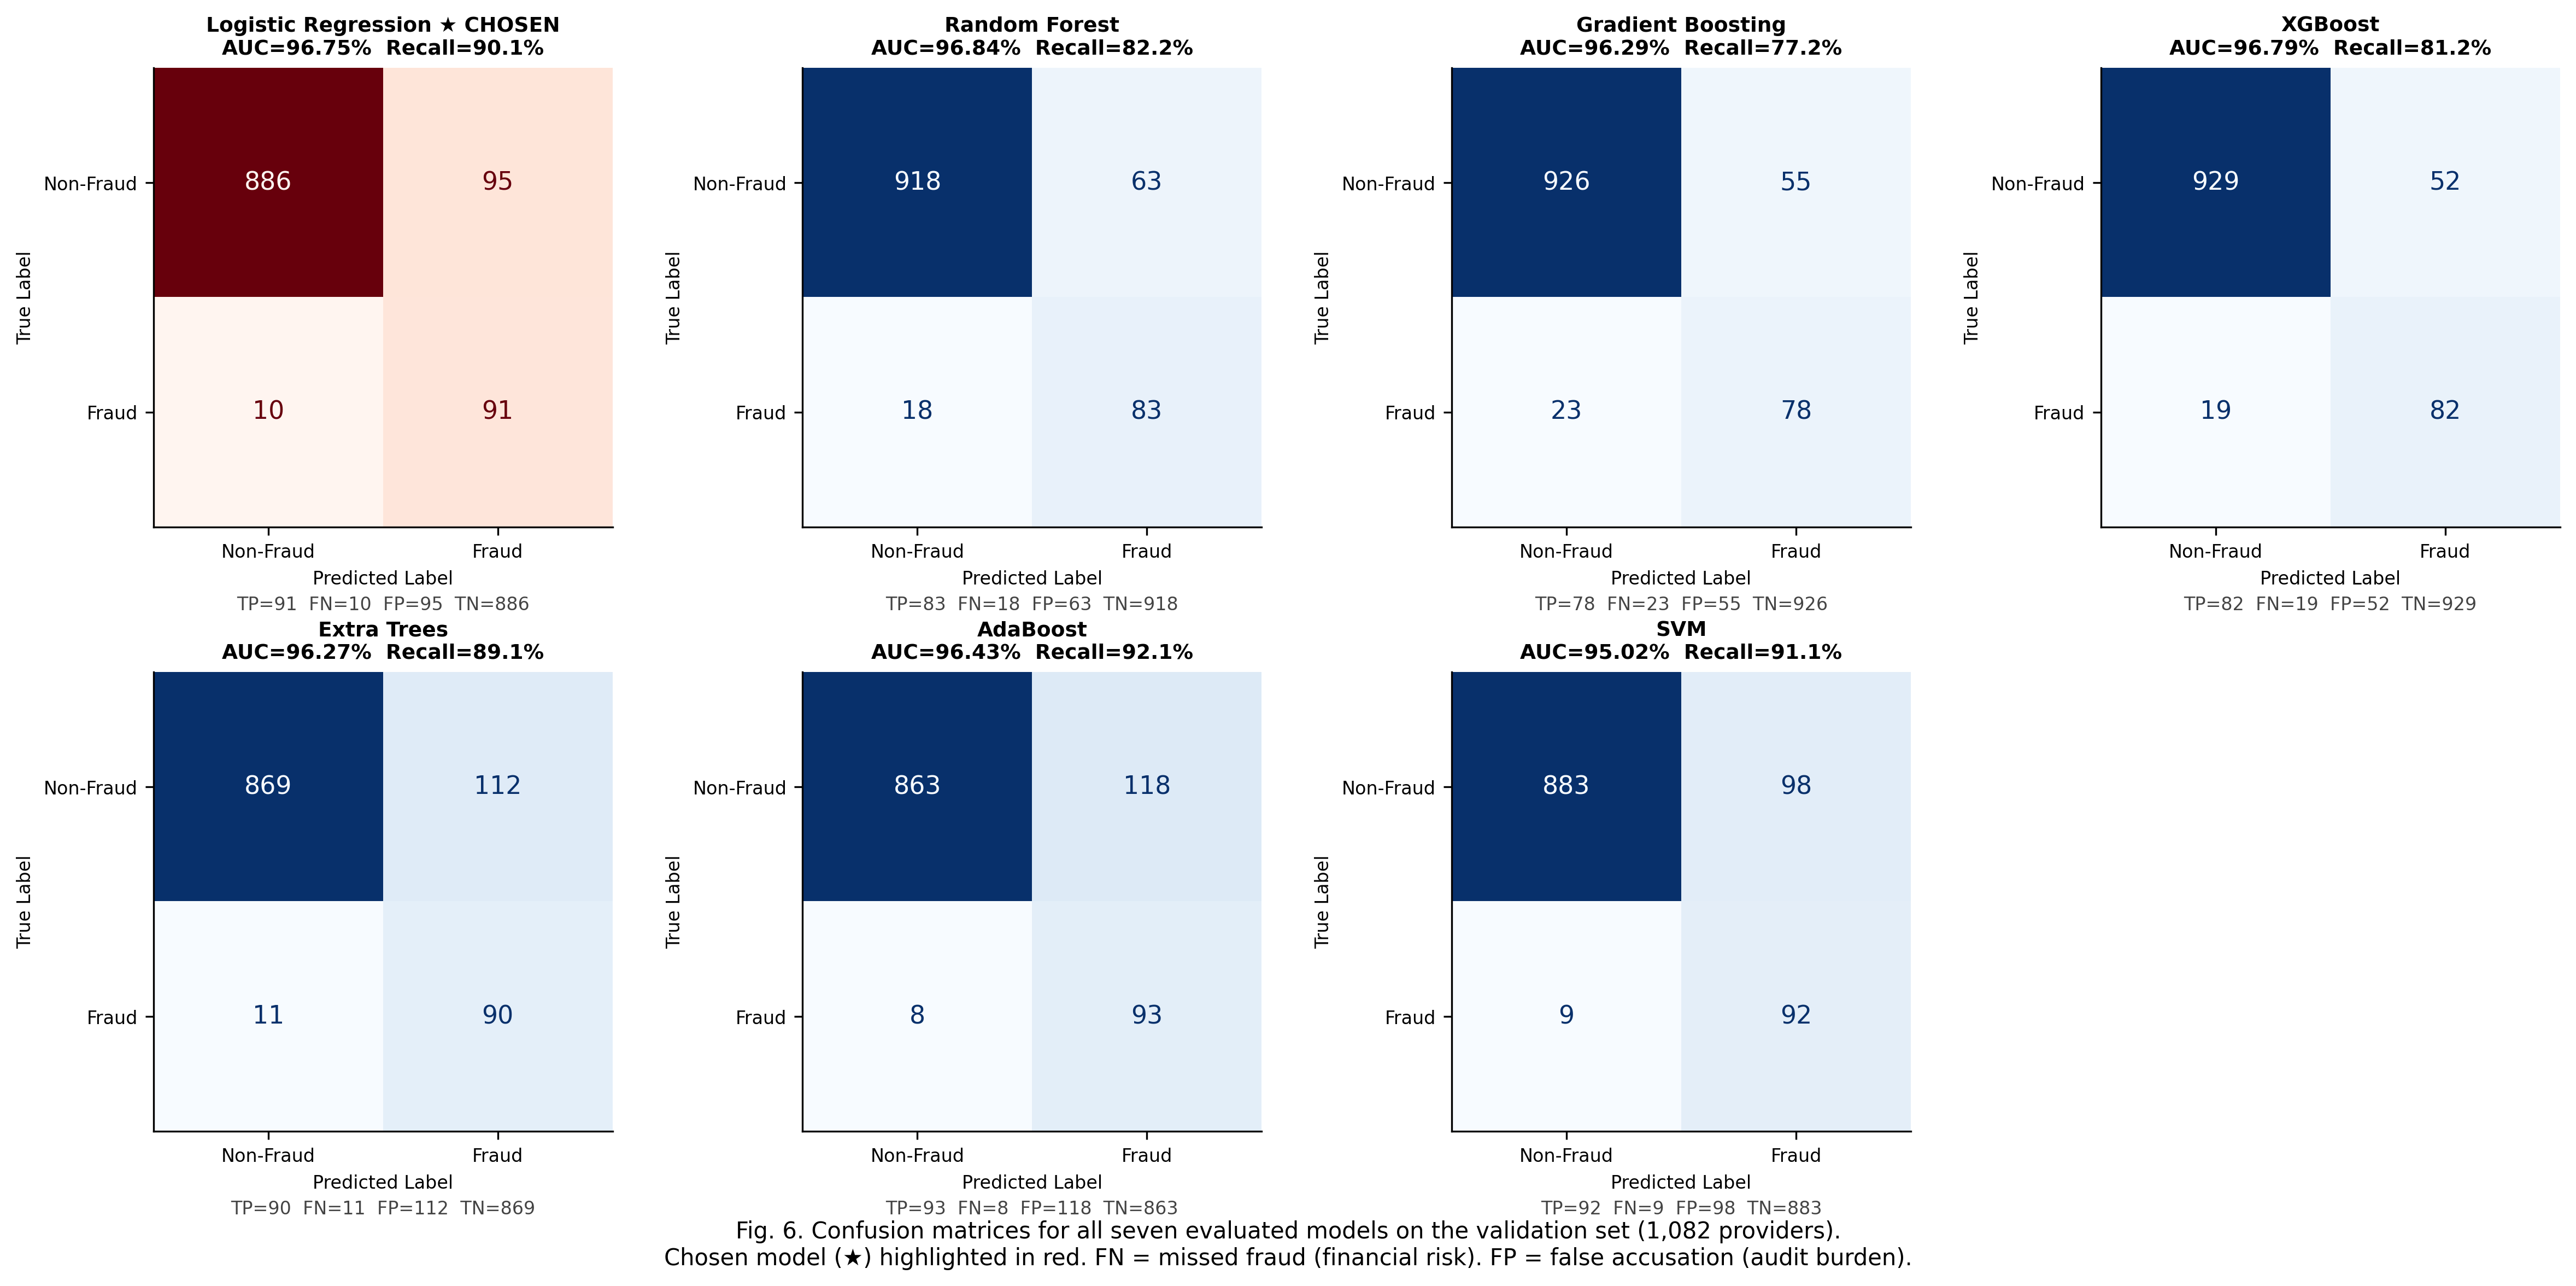

CLINICAL INTERPRETATION FOR PAPER (Discussion section):

Logistic Regression ★:
  TP= 91 fraud caught  |  FN= 10 fraud MISSED  |  FP= 95 wrongly flagged  |  TN=886 correctly cleared
Random Forest:
  TP= 83 fraud caught  |  FN= 18 fraud MISSED  |  FP= 63 wrongly flagged  |  TN=918 correctly cleared
Gradient Boosting:
  TP= 78 fraud caught  |  FN= 23 fraud MISSED  |  FP= 55 wrongly flagged  |  TN=926 correctly cleared
XGBoost:
  TP= 82 fraud caught  |  FN= 19 fraud MISSED  |  FP= 52 wrongly flagged  |  TN=929 correctly cleared
Extra Trees:
  TP= 90 fraud caught  |  FN= 11 fraud MISSED  |  FP=112 wrongly flagged  |  TN=869 correctly cleared
AdaBoost:
  TP= 93 fraud caught  |  FN=  8 fraud MISSED  |  FP=118 wrongly flagged  |  TN=863 correctly cleared
SVM:
  TP= 92 fraud caught  |  FN=  9 fraud MISSED  |  FP= 98 wrongly flagged  |  TN=883 correctly cleared

Saved: ../paper/figures/fig06_confusion_matrices_all.png


In [23]:
n_models = len(results)
cols     = 4
rows_grid = (n_models + cols - 1) // cols   # ceiling division → 2 rows

fig, axes = plt.subplots(rows_grid, cols,
                         figsize=(cols * 4, rows_grid * 4))
axes_flat = axes.flatten()

for idx, (name, r) in enumerate(results.items()):
    ax = axes_flat[idx]
    cm = r['cm']
    tn, fp, fn, tp = cm.ravel()

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Non-Fraud', 'Fraud']
    )
    disp.plot(ax=ax, colorbar=False,
              cmap='Blues' if name != CHOSEN_MODEL else 'Reds')

    star = ' ★ CHOSEN' if name == CHOSEN_MODEL else ''
    ax.set_title(f'{name}{star}\nAUC={r["val_auc"]*100:.2f}%  Recall={r["recall"]*100:.1f}%',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=8)
    ax.set_ylabel('True Label', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.text(0.5, -0.18,
            f'TP={tp}  FN={fn}  FP={fp}  TN={tn}',
            transform=ax.transAxes, ha='center', fontsize=8, color='#444')

# Hide unused subplots
for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(
    'Fig. 6. Confusion matrices for all seven evaluated models on the validation set (1,082 providers).\n'
    'Chosen model (★) highlighted in red. FN = missed fraud (financial risk). FP = false accusation (audit burden).',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig06_confusion_matrices_all.png')
plt.show()

# Clinical interpretation for paper
print("CLINICAL INTERPRETATION FOR PAPER (Discussion section):")
print()
for name, r in results.items():
    tn, fp, fn, tp = r['cm'].ravel()
    star = ' ★' if name == CHOSEN_MODEL else ''
    print(f"{name}{star}:")
    print(f"  TP={tp:3d} fraud caught  |  FN={fn:3d} fraud MISSED  |  FP={fp:3d} wrongly flagged  |  TN={tn:3d} correctly cleared")

print(f"\nSaved: {FIG}fig06_confusion_matrices_all.png")

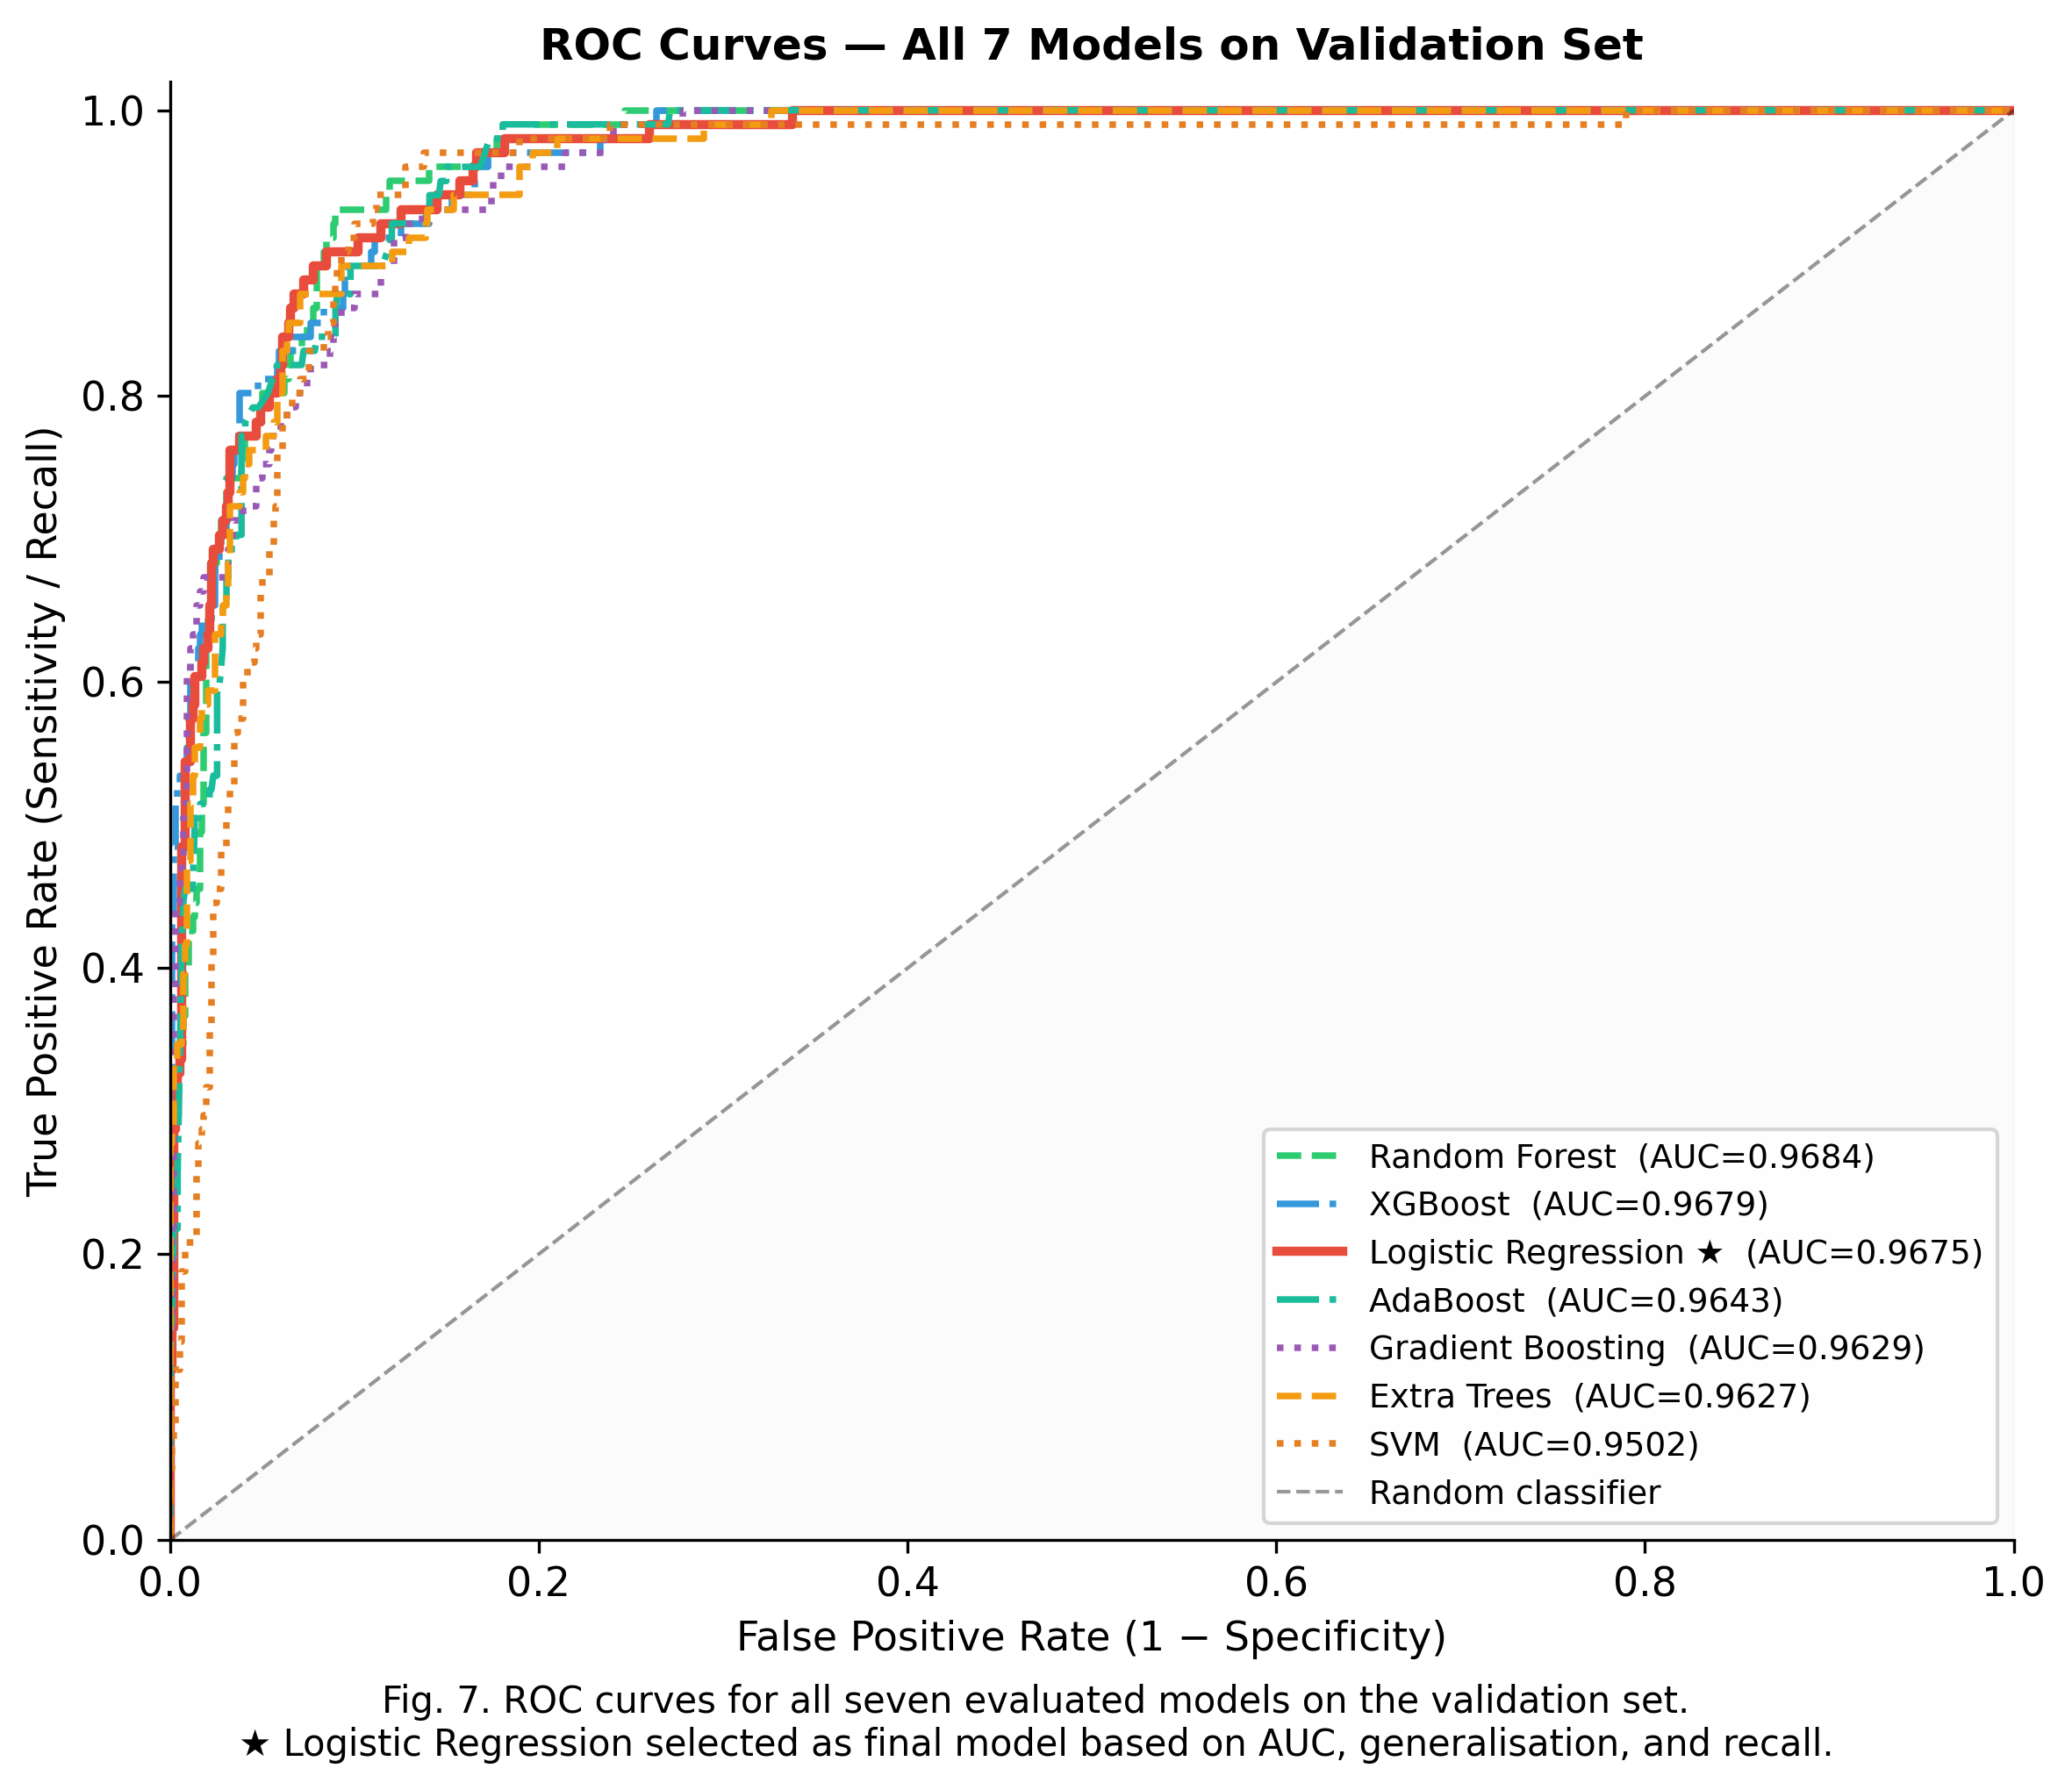

Saved: ../paper/figures/fig07_roc_curves_all.png


In [24]:
# Distinct colors and linestyles for all 7
style_map = {
    'Logistic Regression': ('#e74c3c', '-',   2.5),
    'Random Forest':       ('#2ecc71', '--',  1.8),
    'XGBoost':             ('#3498db', '-.',  1.8),
    'Gradient Boosting':   ('#9b59b6', ':',   1.8),
    'Extra Trees':         ('#f39c12', '--',  1.8),
    'AdaBoost':            ('#1abc9c', '-.',  1.8),
    'SVM':                 ('#e67e22', ':',   1.8),
}

fig, ax = plt.subplots(figsize=(8, 7))

for name, r in sorted(results.items(),
                       key=lambda x: x[1]['val_auc'], reverse=True):
    color, ls, lw = style_map.get(name, ('#888888', '-', 1.5))
    star = ' ★' if name == CHOSEN_MODEL else ''
    ax.plot(r['fpr'], r['tpr'],
            color=color, linestyle=ls, linewidth=lw,
            label=f"{name}{star}  (AUC={r['val_auc']:.4f})")

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.4, label='Random classifier')
ax.fill_between([0,1],[0,1], alpha=0.03, color='gray')
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
ax.set_title('ROC Curves — All 7 Models on Validation Set', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

fig.suptitle(
    'Fig. 7. ROC curves for all seven evaluated models on the validation set.\n'
    '★ Logistic Regression selected as final model based on AUC, generalisation, and recall.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig07_roc_curves_all.png')
plt.show()
print(f"Saved: {FIG}fig07_roc_curves_all.png")

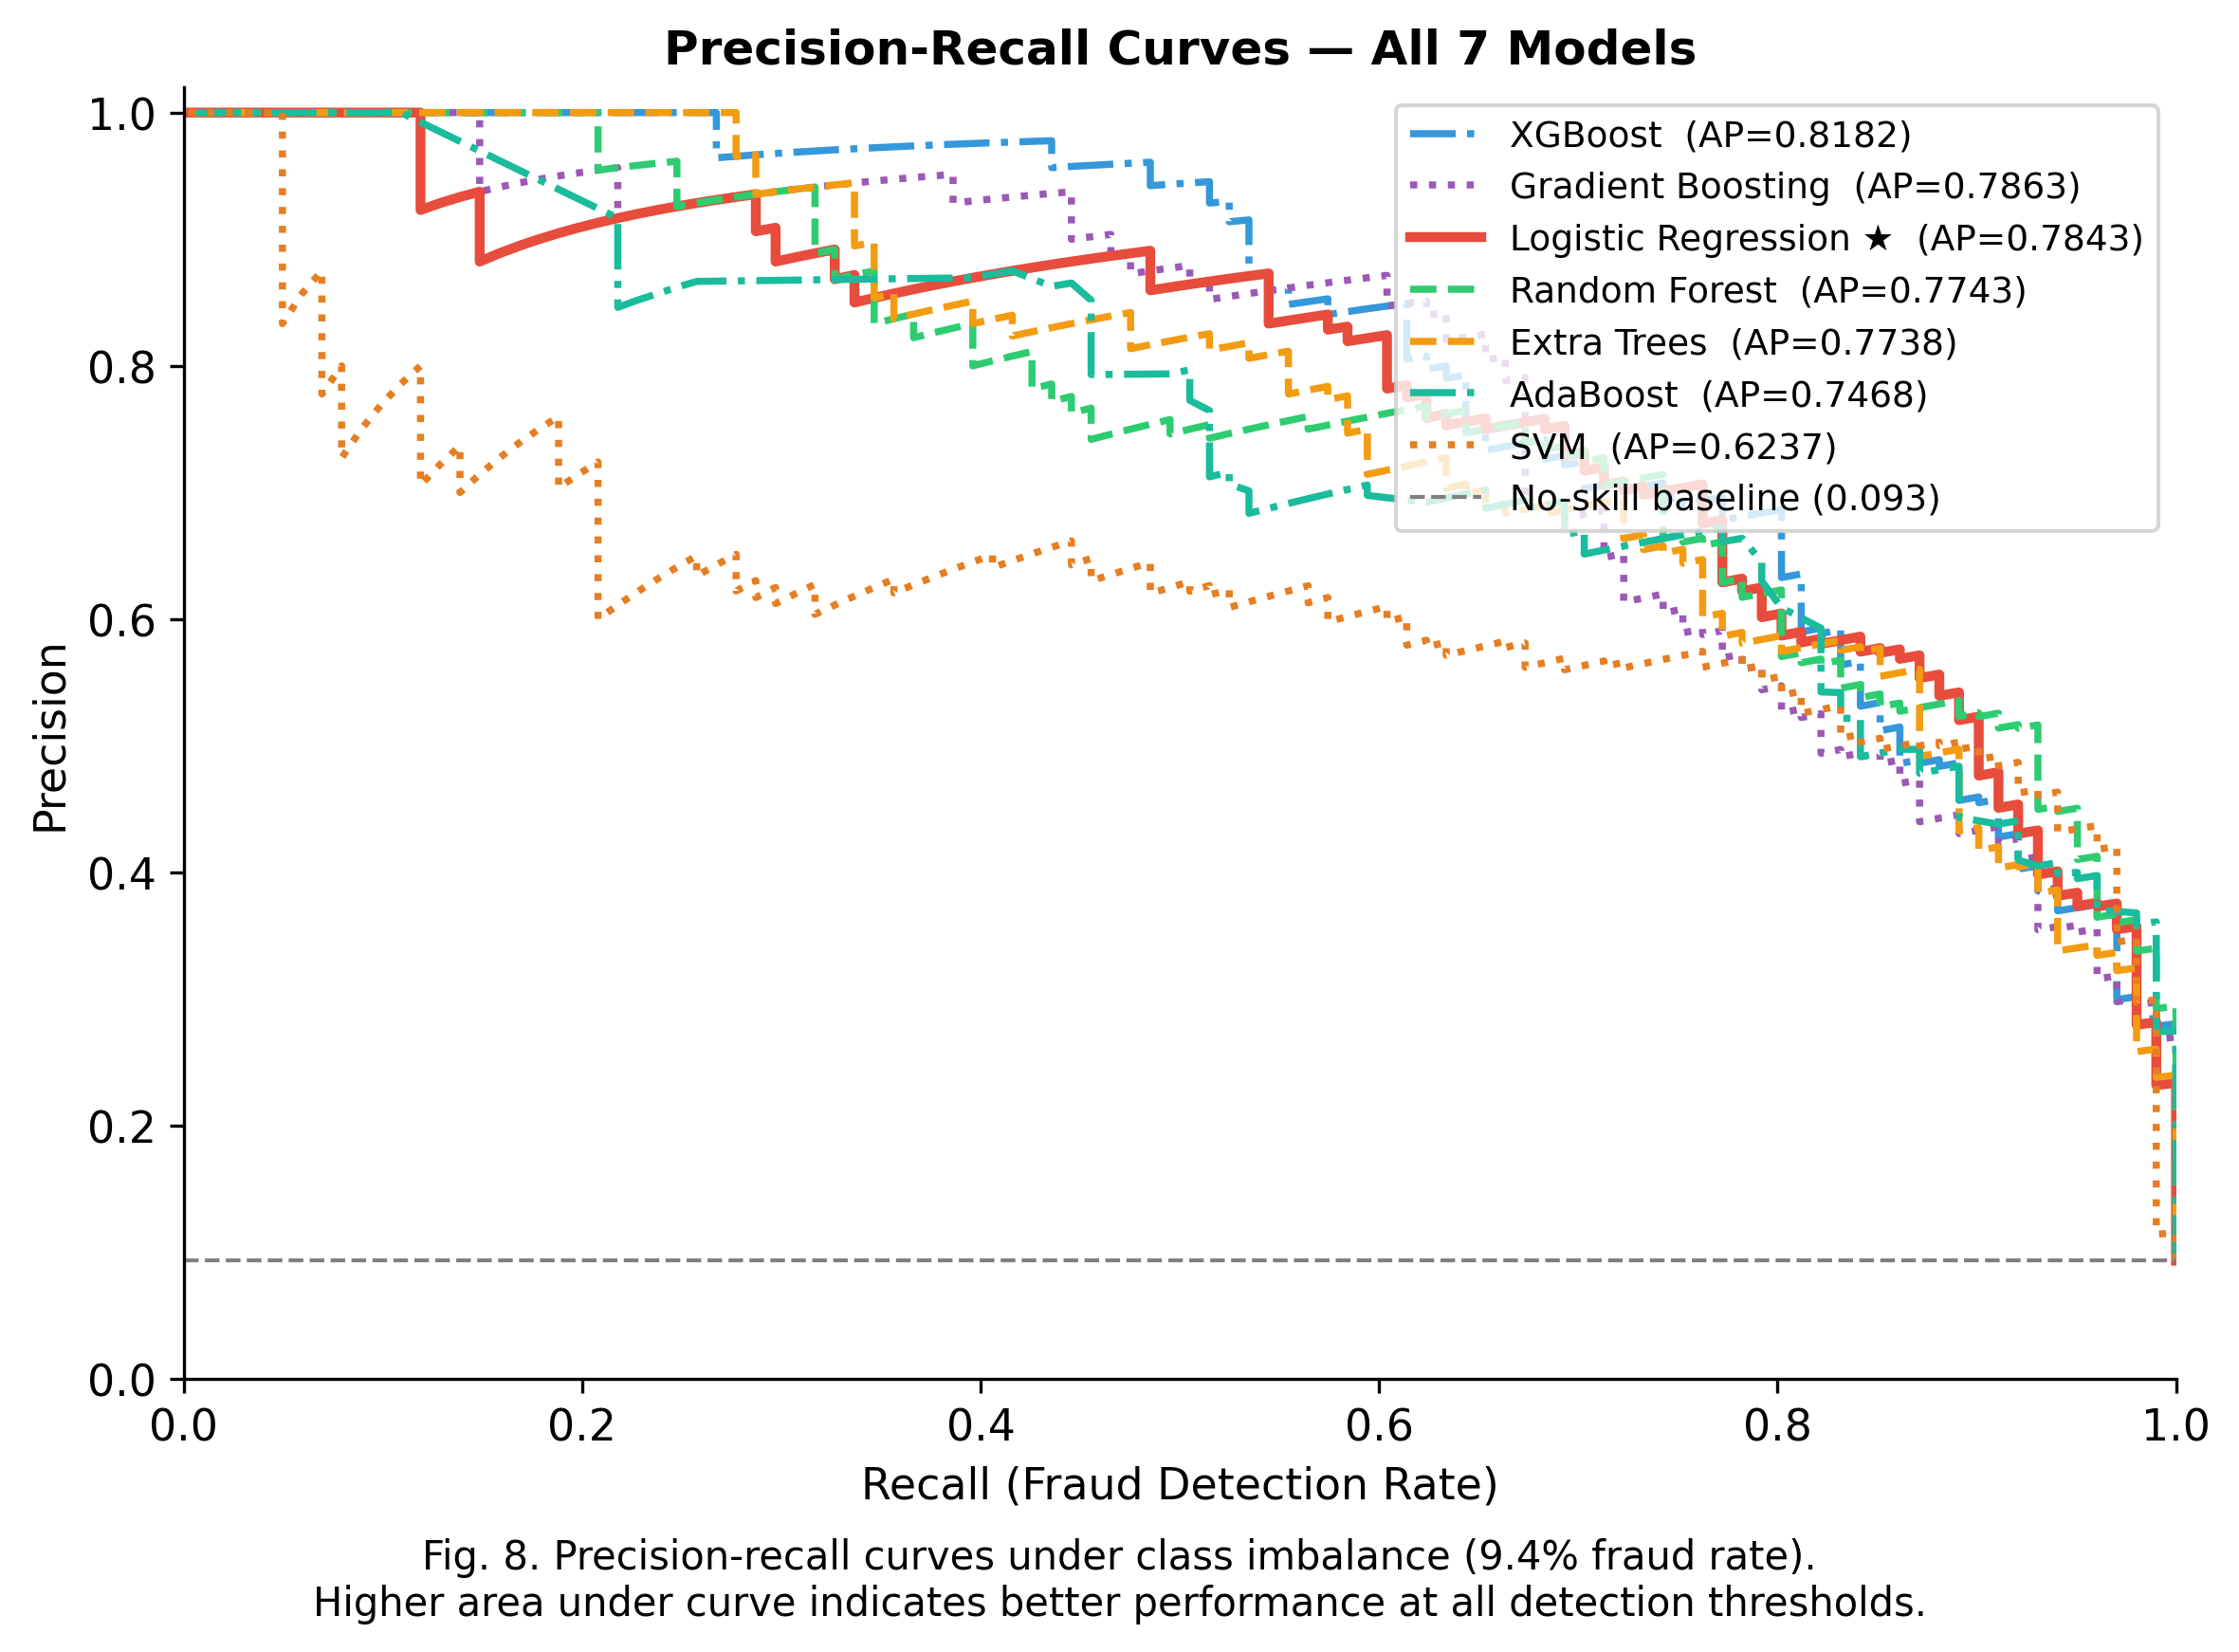

Saved: ../paper/figures/fig08_precision_recall_all.png


In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, r in sorted(results.items(),
                       key=lambda x: x[1]['avg_prec'], reverse=True):
    color, ls, lw = style_map.get(name, ('#888888', '-', 1.5))
    prec_c, rec_c, _ = precision_recall_curve(y_val, r['y_proba'])
    star = ' ★' if name == CHOSEN_MODEL else ''
    ax.plot(rec_c, prec_c,
            color=color, linestyle=ls, linewidth=lw,
            label=f"{name}{star}  (AP={r['avg_prec']:.4f})")

baseline = y_val.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
           label=f'No-skill baseline ({baseline:.3f})')
ax.set_xlabel('Recall (Fraud Detection Rate)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves — All 7 Models', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

fig.suptitle(
    'Fig. 8. Precision-recall curves under class imbalance (9.4% fraud rate).\n'
    'Higher area under curve indicates better performance at all detection thresholds.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig08_precision_recall_all.png')
plt.show()
print(f"Saved: {FIG}fig08_precision_recall_all.png")

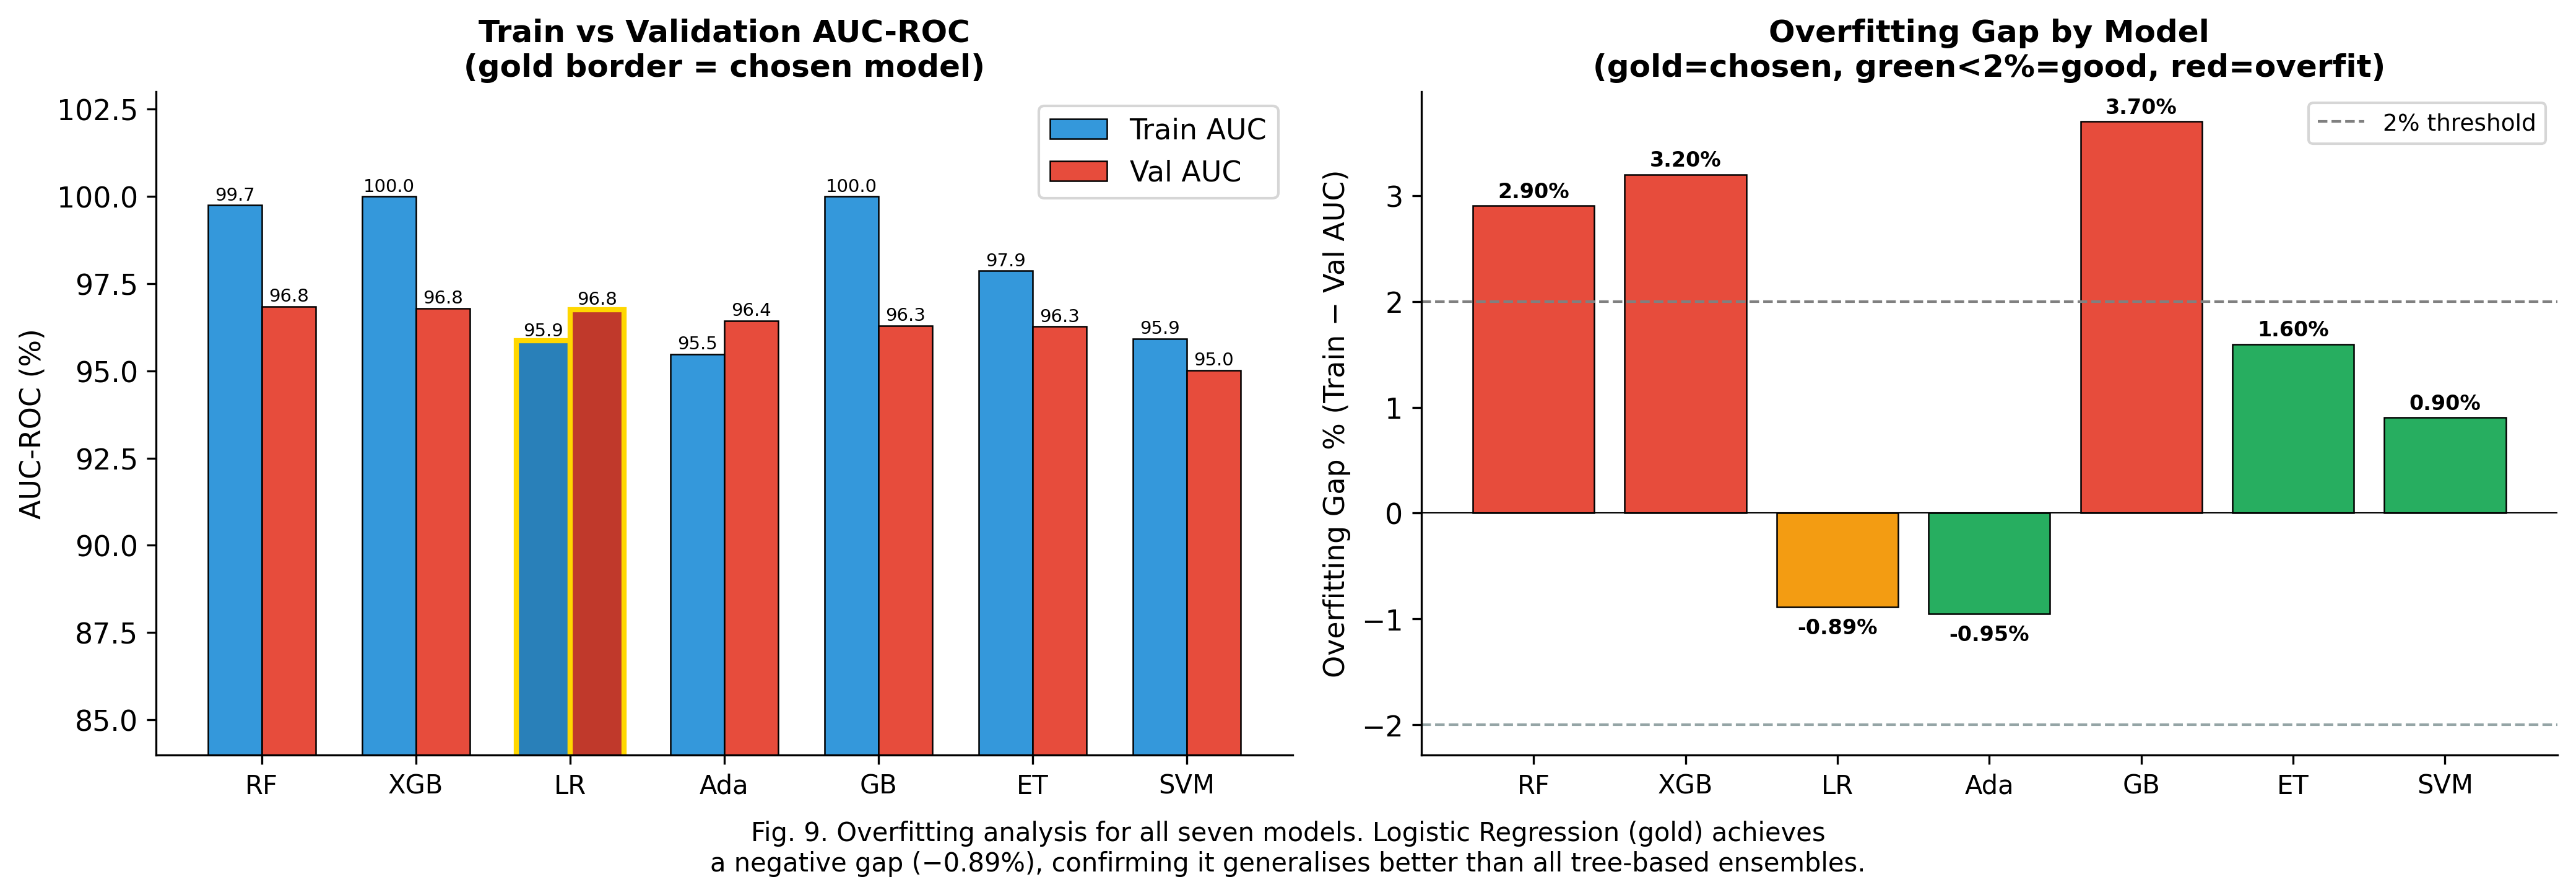

Saved: ../paper/figures/fig09_overfitting_analysis_all.png


In [26]:
sorted_names = sorted(results.keys(),
                      key=lambda m: results[m]['val_auc'], reverse=True)
short = {'Logistic Regression':'LR','Random Forest':'RF',
         'XGBoost':'XGB','Gradient Boosting':'GB',
         'Extra Trees':'ET','AdaBoost':'Ada','SVM':'SVM'}

labels      = [short.get(m, m)     for m in sorted_names]
val_auc_v   = [results[m]['val_auc']*100   for m in sorted_names]
train_auc_v = [results[m]['train_auc']*100 for m in sorted_names]
gap_v       = [results[m]['train_auc']*100 - results[m]['val_auc']*100
               for m in sorted_names]
recall_v    = [results[m]['recall']*100    for m in sorted_names]

x = np.arange(len(sorted_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Train vs Val AUC ──────────────────────────────────────
b1 = axes[0].bar(x - w/2, train_auc_v, w, label='Train AUC',
                 color='#3498db', edgecolor='black', linewidth=0.6)
b2 = axes[0].bar(x + w/2, val_auc_v,   w, label='Val AUC',
                 color='#e74c3c', edgecolor='black', linewidth=0.6)

# Highlight chosen model bars
chosen_idx = sorted_names.index(CHOSEN_MODEL)
axes[0].bar(chosen_idx - w/2, train_auc_v[chosen_idx], w,
            color='#2980b9', edgecolor='gold', linewidth=2)
axes[0].bar(chosen_idx + w/2, val_auc_v[chosen_idx],   w,
            color='#c0392b', edgecolor='gold', linewidth=2)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel('AUC-ROC (%)')
axes[0].set_title('Train vs Validation AUC-ROC\n(gold border = chosen model)')
axes[0].set_ylim([84, 103])
axes[0].legend()
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                 f'{bar.get_height():.1f}', ha='center', fontsize=7)
for bar in b2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                 f'{bar.get_height():.1f}', ha='center', fontsize=7)

# ── Right: Overfitting gap ──────────────────────────────────────
gap_colors = []
for i, (g, name) in enumerate(zip(gap_v, sorted_names)):
    if name == CHOSEN_MODEL:
        gap_colors.append('#f39c12')   # gold for chosen
    elif abs(g) < 2:
        gap_colors.append('#27ae60')   # green = good
    else:
        gap_colors.append('#e74c3c')   # red = overfit

bars = axes[1].bar(x, gap_v, color=gap_colors,
                   edgecolor='black', linewidth=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylabel('Overfitting Gap % (Train − Val AUC)')
axes[1].set_title('Overfitting Gap by Model\n(gold=chosen, green<2%=good, red=overfit)')
axes[1].axhline(y=2,  color='gray',    linestyle='--', linewidth=1, label='2% threshold')
axes[1].axhline(y=0,  color='black',   linestyle='-',  linewidth=0.5)
axes[1].axhline(y=-2, color='#95a5a6', linestyle='--', linewidth=1)
axes[1].legend(fontsize=9)
for i, g in enumerate(gap_v):
    axes[1].text(i, g + (0.08 if g >= 0 else -0.25),
                 f'{g:.2f}%', ha='center', fontsize=8, fontweight='bold')

fig.suptitle(
    'Fig. 9. Overfitting analysis for all seven models. Logistic Regression (gold) achieves\n'
    'a negative gap (−0.89%), confirming it generalises better than all tree-based ensembles.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig09_overfitting_analysis_all.png')
plt.show()
print(f"Saved: {FIG}fig09_overfitting_analysis_all.png")

In [14]:
print("=" * 70)
print("RUNTIME TABLE — ALL 7 MODELS — PAPER TABLE III (Mentor Point 8)")
print("=" * 70)

runtime_rows = []
for name in sorted(runtimes.keys(),
                   key=lambda m: results[m]['val_auc'], reverse=True):
    times = runtimes[name]
    star  = ' ★' if name == CHOSEN_MODEL else ''
    runtime_rows.append({
        'Model':              name + star,
        'Train Time (s)':     times['train_time_s'],
        'Pred Time (s)':      times['pred_time_s'],
        'Val AUC (%)':        round(results[name]['val_auc']*100, 2),
        'Samples Trained On': X_train.shape[0],
        'Samples Predicted':  X_val.shape[0],
    })

runtime_df = pd.DataFrame(runtime_rows)
print(runtime_df.to_string(index=False))
runtime_df.to_csv(RES + 'runtime_table.csv', index=False)

print()
print("MANUALLY ADD THESE TO THE SAVED CSV AFTER PHASE 5:")
print("  | Data Preprocessing    | (time from Phase 2 Cell timings) |")
print("  | Blockchain Storage/record | (measured in Phase 5)         |")
print("  | Blockchain Retrieval/record | (measured in Phase 5)       |")
print(f"\nSaved: {RES}runtime_table.csv")

RUNTIME TABLE — ALL 7 MODELS — PAPER TABLE III (Mentor Point 8)
                Model  Train Time (s)  Pred Time (s)  Val AUC (%)  Samples Trained On  Samples Predicted
        Random Forest           1.523         0.0898        96.84                7846               1082
              XGBoost           0.769         0.0036        96.79                7846               1082
Logistic Regression ★           0.237         0.0000        96.75                7846               1082
             AdaBoost           4.441         0.0475        96.43                7846               1082
    Gradient Boosting          18.344         0.0109        96.29                7846               1082
          Extra Trees           0.284         0.0921        96.27                7846               1082
                  SVM          12.157         0.4950        95.02                7846               1082

MANUALLY ADD THESE TO THE SAVED CSV AFTER PHASE 5:
  | Data Preprocessing    | (time from Phase

In [27]:
print("=" * 60)
print("SAVING ALL MODELS AND TEST PREDICTIONS")
print("=" * 60)

# Save all 7 models
for name, r in results.items():
    fname = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(r['model'], MODELS + fname)
    print(f"Saved: models/{fname}")

# Save best model with standard name for dashboard
best_model = results[CHOSEN_MODEL]['model']
joblib.dump(best_model, MODELS + 'best_model.pkl')
print(f"Saved: models/best_model.pkl  ({CHOSEN_MODEL})")

# Save scaler reference
scaler = joblib.load(MODELS + 'scaler.pkl')
print(f"Confirmed: models/scaler.pkl  exists")

# Generate test predictions with chosen model
test_master  = pd.read_csv('../data/processed/test_master.csv')
test_proba   = best_model.predict_proba(X_test)[:, 1]
test_pred    = best_model.predict(X_test)

def risk_category(p):
    if p >= 0.7:   return 'High'
    elif p >= 0.4: return 'Medium'
    else:          return 'Low'

test_results_df = pd.DataFrame({
    'Provider':         test_master['Provider'],
    'FraudPrediction':  test_pred,
    'FraudProbability': test_proba.round(4),
    'RiskCategory':     [risk_category(p) for p in test_proba],
})
test_results_df.to_csv(RES + 'test_predictions.csv', index=False)

print()
print("Test predictions summary:")
print(f"  Total providers:   {len(test_pred)}")
print(f"  Flagged as fraud:  {test_pred.sum()} ({test_pred.mean()*100:.1f}%)")
print()
print("Risk category breakdown:")
print(test_results_df['RiskCategory'].value_counts().to_string())
print()
print(f"Saved: {RES}test_predictions.csv")

# Save all model metrics together for dashboard
all_metrics = []
for name, r in results.items():
    gap = r['train_auc'] - r['val_auc']
    tn, fp, fn, tp_val = r['cm'].ravel()
    all_metrics.append({
        'Model':        name,
        'IsChosen':     name == CHOSEN_MODEL,
        'Accuracy':     round(r['accuracy']*100,  4),
        'Precision':    round(r['precision']*100, 4),
        'Recall':       round(r['recall']*100,    4),
        'F1':           round(r['f1']*100,        4),
        'ValAUC':       round(r['val_auc']*100,   4),
        'TrainAUC':     round(r['train_auc']*100, 4),
        'OverfitGap':   round(gap*100,            4),
        'TP': int(tp_val), 'FN': int(fn),
        'FP': int(fp),     'TN': int(tn),
        'TrainTime':    runtimes[name]['train_time_s'],
        'PredTime':     runtimes[name]['pred_time_s'],
    })

pd.DataFrame(all_metrics).to_csv(RES + 'all_metrics_for_dashboard.csv', index=False)
print(f"Saved: {RES}all_metrics_for_dashboard.csv")

SAVING ALL MODELS AND TEST PREDICTIONS
Saved: models/logistic_regression.pkl
Saved: models/random_forest.pkl
Saved: models/gradient_boosting.pkl
Saved: models/xgboost.pkl
Saved: models/extra_trees.pkl
Saved: models/adaboost.pkl
Saved: models/svm.pkl
Saved: models/best_model.pkl  (Logistic Regression)
Confirmed: models/scaler.pkl  exists

Test predictions summary:
  Total providers:   1353
  Flagged as fraud:  231 (17.1%)

Risk category breakdown:
RiskCategory
Low       1097
High       172
Medium      84

Saved: ../results/test_predictions.csv
Saved: ../results/all_metrics_for_dashboard.csv


In [28]:
print("=" * 65)
print("PHASE 3 COMPLETE — ALL NUMBERS FOR YOUR PAPER")
print("=" * 65)

chosen = results[CHOSEN_MODEL]
tn, fp, fn, tp_val = chosen['cm'].ravel()

print(f"\nChosen model: {CHOSEN_MODEL}")
print(f"  Accuracy:      {chosen['accuracy']*100:.2f}%")
print(f"  Precision:     {chosen['precision']*100:.2f}%")
print(f"  Recall:        {chosen['recall']*100:.2f}%")
print(f"  F1-Score:      {chosen['f1']*100:.2f}%")
print(f"  Val AUC-ROC:   {chosen['val_auc']*100:.2f}%")
print(f"  Train AUC:     {chosen['train_auc']*100:.2f}%")
print(f"  Overfit Gap:   {(chosen['train_auc']-chosen['val_auc'])*100:.2f}%")
print(f"  TP={tp_val}  FN={fn}  FP={fp}  TN={tn}")

print()
print("All 7 models ranked:")
for i, (name, r) in enumerate(
        sorted(results.items(),
               key=lambda x: x[1]['val_auc'], reverse=True), 1):
    gap  = (r['train_auc'] - r['val_auc'])*100
    star = ' ★ CHOSEN' if name == CHOSEN_MODEL else ''
    print(f"  {i}. {name:<22} AUC={r['val_auc']*100:.2f}%  "
          f"Gap={gap:.2f}%  Recall={r['recall']*100:.2f}%{star}")

print()
print("Figures saved to paper/figures/:")
for f in sorted(os.listdir(FIG)):
    if f.startswith('fig0'):
        print(f"  {f}")

print()
print("Models saved to models/:")
for f in sorted(os.listdir(MODELS)):
    print(f"  {f}")

print()
print("Results saved to results/:")
for f in sorted(os.listdir(RES)):
    size = os.path.getsize(RES + f) / 1024
    print(f"  {f:<40} {size:.1f} KB")

print()
print("NEXT: Phase 4 — SHAP Explainable AI")
print(f"  Model to explain: {CHOSEN_MODEL}")
print(f"  SHAP type: LinearExplainer (exact, fast)")
print(f"  Features to explain: {len(feat_names)}")

PHASE 3 COMPLETE — ALL NUMBERS FOR YOUR PAPER

Chosen model: Logistic Regression
  Accuracy:      90.30%
  Precision:     48.92%
  Recall:        90.10%
  F1-Score:      63.41%
  Val AUC-ROC:   96.75%
  Train AUC:     95.86%
  Overfit Gap:   -0.89%
  TP=91  FN=10  FP=95  TN=886

All 7 models ranked:
  1. Random Forest          AUC=96.84%  Gap=2.90%  Recall=82.18%
  2. XGBoost                AUC=96.79%  Gap=3.20%  Recall=81.19%
  3. Logistic Regression    AUC=96.75%  Gap=-0.89%  Recall=90.10% ★ CHOSEN
  4. AdaBoost               AUC=96.43%  Gap=-0.95%  Recall=92.08%
  5. Gradient Boosting      AUC=96.29%  Gap=3.70%  Recall=77.23%
  6. Extra Trees            AUC=96.27%  Gap=1.60%  Recall=89.11%
  7. SVM                    AUC=95.02%  Gap=0.90%  Recall=91.09%

Figures saved to paper/figures/:
  fig01_class_distribution.png
  fig02_stay_duration.png
  fig03_claim_amounts.png
  fig04_feature_correlation.png
  fig05_model_comparison.png
  fig06_confusion_matrices_all.png
  fig07_roc_curves_a

THRESHOLD ANALYSIS — FIND OPTIMAL CUTOFF

Default threshold (0.50):
  Precision: 48.92%
  Recall:    90.10%
  F1:        63.41%
  Fraud flagged: 186 / 1082

Optimal threshold (0.82) — maximises F1:
  Precision: 70.64%
  Recall:    76.24%
  F1:        73.33%
  Fraud flagged: 109 / 1082


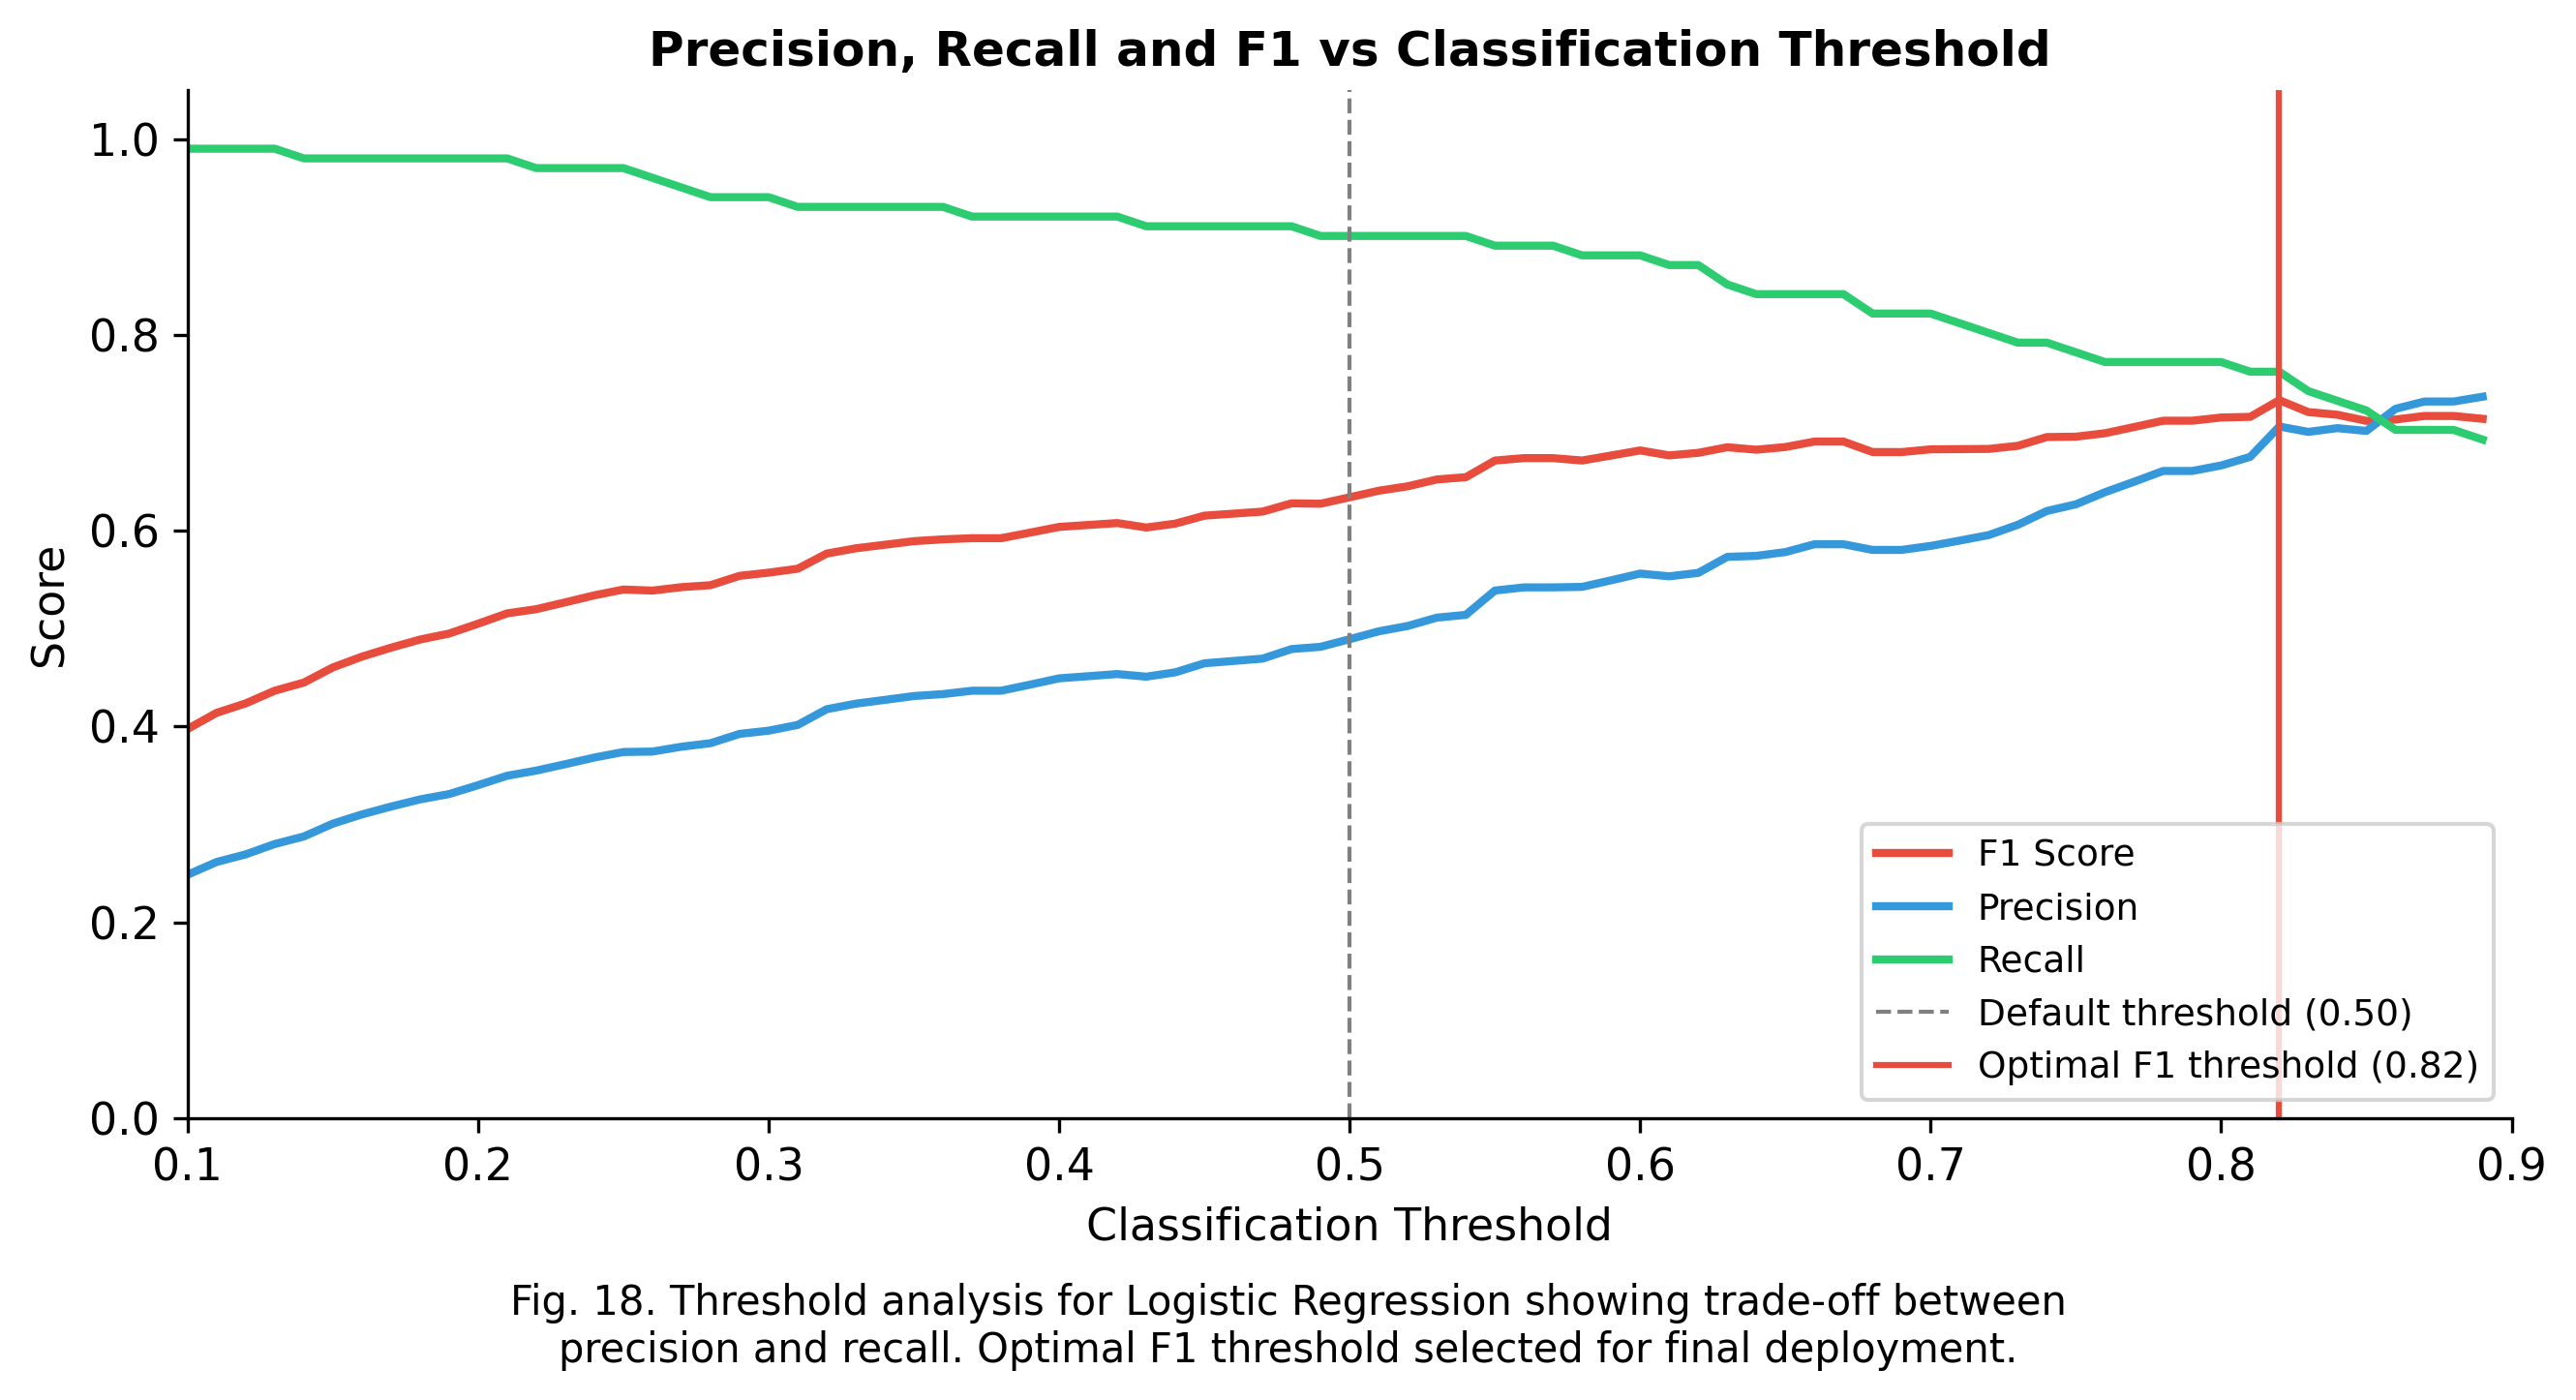


Conclusion:
  Use threshold = 0.82 for final predictions
  This balances catching fraud (recall) vs false alarms (precision)
  Save this value — use it in blockchain storage and dashboard
Saved: ../results/optimal_threshold.json


In [29]:
print("=" * 60)
print("THRESHOLD ANALYSIS — FIND OPTIMAL CUTOFF")
print("=" * 60)

from sklearn.metrics import f1_score, precision_score, recall_score

lr_model  = results['Logistic Regression']['model']
y_proba   = results['Logistic Regression']['y_proba']

thresholds   = np.arange(0.1, 0.9, 0.01)
f1_scores    = []
precisions   = []
recalls      = []
aucs         = []

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_val, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_val, y_pred_t, zero_division=0))

best_f1_idx   = np.argmax(f1_scores)
best_thresh   = thresholds[best_f1_idx]

print(f"\nDefault threshold (0.50):")
y_default = (y_proba >= 0.50).astype(int)
print(f"  Precision: {precision_score(y_val, y_default)*100:.2f}%")
print(f"  Recall:    {recall_score(y_val, y_default)*100:.2f}%")
print(f"  F1:        {f1_score(y_val, y_default)*100:.2f}%")
print(f"  Fraud flagged: {y_default.sum()} / {len(y_default)}")

print(f"\nOptimal threshold ({best_thresh:.2f}) — maximises F1:")
y_optimal = (y_proba >= best_thresh).astype(int)
print(f"  Precision: {precision_score(y_val, y_optimal)*100:.2f}%")
print(f"  Recall:    {recall_score(y_val, y_optimal)*100:.2f}%")
print(f"  F1:        {f1_score(y_val, y_optimal)*100:.2f}%")
print(f"  Fraud flagged: {y_optimal.sum()} / {len(y_optimal)}")

# Plot threshold curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1_scores,   color='#e74c3c', linewidth=2, label='F1 Score')
ax.plot(thresholds, precisions,  color='#3498db', linewidth=2, label='Precision')
ax.plot(thresholds, recalls,     color='#2ecc71', linewidth=2, label='Recall')
ax.axvline(x=0.50,         color='gray',    linestyle='--', linewidth=1,
           label='Default threshold (0.50)')
ax.axvline(x=best_thresh,  color='#e74c3c', linestyle='-',  linewidth=1.5,
           label=f'Optimal F1 threshold ({best_thresh:.2f})')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall and F1 vs Classification Threshold')
ax.legend(fontsize=9)
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0, 1.05])
fig.suptitle(
    'Fig. 18. Threshold analysis for Logistic Regression showing trade-off between\n'
    'precision and recall. Optimal F1 threshold selected for final deployment.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig('../paper/figures/fig18_threshold_analysis.png')
plt.show()

print(f"\nConclusion:")
print(f"  Use threshold = {best_thresh:.2f} for final predictions")
print(f"  This balances catching fraud (recall) vs false alarms (precision)")
print(f"  Save this value — use it in blockchain storage and dashboard")

# Save optimal threshold
import json
with open('../results/optimal_threshold.json', 'w') as f:
    json.dump({'optimal_threshold': float(best_thresh),
               'default_threshold': 0.50,
               'best_f1': float(f1_scores[best_f1_idx])}, f, indent=2)
print(f"Saved: ../results/optimal_threshold.json")

In [30]:
import joblib, pandas as pd, numpy as np

# Load optimal threshold
with open('../results/optimal_threshold.json') as f:
    thresh_data  = json.load(f)
THRESHOLD = thresh_data['optimal_threshold']

print(f"Using optimal threshold: {THRESHOLD:.2f}")

# Regenerate test predictions
X_test     = np.load('../data/processed/X_test_scaled.npy')
test_master = pd.read_csv('../data/processed/test_master.csv')
lr_model    = results['Logistic Regression']['model']
test_proba  = lr_model.predict_proba(X_test)[:, 1]
test_pred   = (test_proba >= THRESHOLD).astype(int)

def risk_category(p):
    if p >= 0.7:   return 'High'
    elif p >= 0.4: return 'Medium'
    else:          return 'Low'

test_results_df = pd.DataFrame({
    'Provider'        : test_master['Provider'],
    'FraudPrediction' : test_pred,
    'FraudProbability': test_proba.round(4),
    'RiskCategory'    : [risk_category(p) for p in test_proba],
})
test_results_df.to_csv('../results/test_predictions.csv', index=False)

print(f"\nUpdated test predictions:")
print(f"  Total providers:  {len(test_pred)}")
print(f"  Predicted fraud:  {test_pred.sum()} ({test_pred.mean()*100:.1f}%)")
print(f"  Predicted clean:  {(test_pred==0).sum()}")
print()
print(f"Risk breakdown:")
print(test_results_df['RiskCategory'].value_counts().to_string())

Using optimal threshold: 0.82

Updated test predictions:
  Total providers:  1353
  Predicted fraud:  134 (9.9%)
  Predicted clean:  1219

Risk breakdown:
RiskCategory
Low       1097
High       172
Medium      84
